In [ ]:
import pandas as pd

In [ ]:
# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)


# orders_qu.csv

url = "https://drive.google.com/file/d/1SVfRD6r23tvenZsmfVSoAA29TYkK2ES8/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qu = pd.read_csv(path)

# orderlines_qu.csv

url = "https://drive.google.com/file/d/1Rn3m4sNK4CVqkHgnYu7a5xMFnzDgIPbz/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qu = pd.read_csv(path)

In [ ]:
category_type_df = products_cl.copy()
orders_df = orders_qu.copy()
orderlines_df = orderlines_qu.copy()

# DEFINING THE PRODUCT CATEGORIES IN THE DATA BASE

## Checking null values in type column

In [ ]:
# Find rows where 'type' is NaN
nan_type = category_type_df[category_type_df['type'].isna()]

# Show SKU, name, and description for those products
print(nan_type[['sku', 'name', 'desc']])

            sku                                               name  \
146     SAN0017       SanDisk Cruzer Edge USB 2.0 Flash Drive 16GB   
362     SAN0026    SanDisk Extreme Cruzer 16GB USB 3.0 Flash Drive   
579     APP0675                    Apple iPhone 5S 32GB Space Gray   
956     APP0823                         Apple iPhone 6 16GB Silver   
961     APP0829                    Apple iPhone 6 Plus 16GB Silver   
962     APP0822                     Apple iPhone 6 16GB Space Gray   
963     APP0825                     Apple iPhone 6 64GB Space Gray   
964     APP0826                         Apple iPhone 6 64GB Silver   
965     APP0828                Apple iPhone 6 Plus 16GB Space Gray   
1042    APP0856                          Apple iPhone 6 128GB Gold   
1043    APP0857                Apple iPhone 6 Plus 64GB Space Gray   
1044    APP0858                    Apple iPhone 6 Plus 64GB Silver   
1045    APP0860               Apple iPhone 6 Plus 128GB Space Gray   
1382    PAC0602     

Notes: Seems like most of the phones products are in the type with NaN value, so it doesn't identify them with the type column

In [ ]:
category_type_df.groupby("type").count().nlargest(30, "sku")

,sku,name,desc,price,in_stock
type,,,,,
11865403,1057,1057,1057,1057,1057
12175397,939,939,939,939,939
1298,783,783,783,783,783
11935397,562,562,562,562,562
11905404,454,454,454,454,454
1282,373,373,373,373,373
12635403,362,362,362,362,362
13835403,269,269,269,269,269
"5,74E+15",247,247,247,247,247


## Checking a sample of 10 products in each type to make the mapping categorization

In [ ]:
# Get the top 30 types
type_counts = category_type_df['type'].value_counts()
top_30_types = type_counts.index[:30].tolist()

# Sample 10 products for each type to inspect
for t in top_30_types:
    print(f"\nType: {t}")
    print(category_type_df.loc[category_type_df['type'] == t, ['sku', 'name', 'desc']].sample(10))


Type: 11865403
          sku                                               name  \
1022  TUC0180             Tucano Fabric Case iPhone 6 Plus Coral   
8746  APP2556             Apple Leather Case iPhone Case X taupe   
5432  GRT0446  Griffin Survivor iPhone Case Journey 8 Plus / ...   
2599  LIF0088     Lifeproof nüüd iPhone 5S Waterproof Case White   
8194  PUR0158                   Pure Blue Hologram X iPhone Case   
6773  APP1994           Apple iPhone Leather Case Cover 8/7 Baya   
6654  THU0045                 Thule Atmos X3 Case Black iPhone 7   
4444  MDT0021  Mediterrans cover iPhone 5 / 5s / SE Costa Bra...   
8737  MOS0236       Moshi Vitros X Transparent Black iPhone Case   
2878  OTT0111     OtterBox iPhone Case 2.0 Symmetry 6 / 6s Beige   

                                                   desc  
1022  Cover for iPhone 6 Plus ultra light polycarbon...  
8746                        Leather case Apple official  
5432  rugged case with shock dispersion system for i...  
259

## Identifying the smartphones category and applying in the category_type_df

In [ ]:
mask = category_type_df['name'].str.startswith(('Apple iPhone', 'Samsung Galaxy', 'Google Pixel', 'Xiaomi', 'OnePlus', 'Huawei'), na=False)
smartphones_df = category_type_df[mask]
print(smartphones_df)

          sku                                               name  \
579   APP0675                    Apple iPhone 5S 32GB Space Gray   
956   APP0823                         Apple iPhone 6 16GB Silver   
961   APP0829                    Apple iPhone 6 Plus 16GB Silver   
962   APP0822                     Apple iPhone 6 16GB Space Gray   
963   APP0825                     Apple iPhone 6 64GB Space Gray   
...       ...                                                ...   
8763  APP2552             Apple iPhone Silicone Case Cover Red X   
8764  APP2553      Apple iPhone Silicone Case Cover X Rosa Arena   
8765  APP2554          Apple iPhone Silicone Case Cover Purple X   
9249  AP20406  Apple iPhone 6S Plus 16GB Space Gray Apple Cer...   
9314  APP2482                          Apple iPhone 8 256GB Gold   

                                                   desc  price  in_stock  \
579               New Free iPhone 5S 32GB (ME435Y / A).  559.0         0   
956               New iPhone 6 

Notes: using the code above it still identify some products that are not related to smartphones, so need to check more in detail

In [ ]:
# Smartphone brands/models
brands = ('Apple iPhone', 'Samsung Galaxy', 'Google Pixel', 'Xiaomi', 'OnePlus', 'Huawei')

# Keywords typical for smartphones
phone_keywords = ['GB', 'storage', 'unlocked', 'phone']

# Accessory terms to exclude
exclude_terms = ['case', 'cover', 'screen', 'battery', 'charger', 'repair', 'headphones', 'dock', 'service', 'silicone']

mask_brand = category_type_df['name'].str.startswith(brands, na=False)
mask_phone = category_type_df['desc'].str.contains('|'.join(phone_keywords), case=False, na=False)
mask_exclude = category_type_df['name'].str.contains('|'.join(exclude_terms), case=False, na=False) | \
               category_type_df['desc'].str.contains('|'.join(exclude_terms), case=False, na=False)

# Only smartphones: brand AND phone keywords, but NOT accessories
smartphones_df = category_type_df[mask_brand & mask_phone & ~mask_exclude]

from IPython.display import display
display(smartphones_df)

,sku,name,desc,price,in_stock,type
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.0,0,NaN
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.0,0,NaN
961,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749.0,0,NaN
962,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639.0,0,NaN
963,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749.0,0,NaN
...,...,...,...,...,...,...
8220,APP2489,Apple iPhone 64GB Space Gray X,New Free iPhone 64GB X,1159.0,1,113271716
8221,APP2495,Apple iPhone 32GB Black Bright 7,New Apple iPhone 32GB Black Free Bright 7,639.0,1,85641716
8222,APP2496,Apple iPhone 7 Plus 32GB Black Bright,New Apple iPhone 7 Plus 32GB Black Free Bright,779.0,0,85651716
9249,AP20406,Apple iPhone 6S Plus 16GB Space Gray Apple Cer...,iPhone 6S Plus Free 16GB Apple Certified Refur...,812.0,1,24811716


In [ ]:
smartphones_df['type'].isna().sum()

np.int64(32)

Notes: since in the type column there are 32 NaN values, I need to fill them with the value: 1234 being smartphones.

In [ ]:
#fill the NaN values with 1234 being smartphones
smartphones_df['type'] = smartphones_df['type'].fillna(1234)

/tmp/ipykernel_5374/853772555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smartphones_df['type'] = smartphones_df['type'].fillna(1234)


In [ ]:
smartphones_df['type'].isna().sum()

np.int64(0)

In [ ]:
category_type_df['type'].isna().sum()

np.int64(46)

Notes: Now, since I filled the NaN values in smartphones_df I want this to be applies as well to the category_type_df

In [ ]:
category_type_df.loc[smartphones_df.index, 'type'] = smartphones_df['type']

In [ ]:
#checking if this has been applied:
category_type_df['type'].isna().sum()

np.int64(14)

## Adding the mapping categories to the product in a new column

## Creating the column category and mapping the categories

In [ ]:
type_category_map = {
    "11865403": "iPhone Cases and Screen Protectors",
    "12175397": "NAS Servers and Storage",
    "1298": "Storage Devices and Accessories",
    "11935397": "External Hard Drive Cases",
    "11905404": "Audio and Music Accessories",
    "1282": "MacBook Pro Laptops",
    "12635403": "iPad Cases and Covers",
    "13835403": "MacBook Cases and Protectors",
    "5,74E+15": "iMac Desktop Computers",
    "1364": "Mac Memory (RAM)",
    "12585395": "Display Adapters",
    "1296": "Computer Monitors",
    "1325": "Display Adapters",
    "5384": "Headphones and Headsets",
    "1433": "SSD Upgrade Kits",
    "12215397": "MacBook Air SSD Expansion Kits",
    "5398": "Bluetooth Speakers",
    "1,02E+12": "MacBook Pro Laptops",
    "1,44E+11": "iPhone Repair Services",
    "57445397": "USB Flash Drives",
    "1334": "Networking Devices & Adapters",
    "2158": "MacBook Pro Laptops",
    "2449": "Apple Watch Accessories",
    "12655397": "Internal Hard Drives",
    "1229": "Stylus and Tablet Accessories",
    "12995397": "Docking Stations and USB Hubs",
    "1515": "Power and Charging Accessories",
    "13615399": "Power and Charging Accessories",
    "13555403": "iPhone Cases and Screen Protectors",
    "1405": "Graphics Tablets and Accessories",
    "1234": "Smartphones"
}

category_type_df['category'] = category_type_df['type'].map(type_category_map).fillna('Other')

In [ ]:
category_type_df.sample(20)

,sku,name,desc,price,in_stock,type,category
4117,BEL0248,Belkin InvisiGlass TrueClear invisible glass P...,Invisible Protector Crystal for iPhone 6s Plus...,19.99,1,13555403,iPhone Cases and Screen Protectors
4840,OSM0008,Osmo Game Starter Kit for iPad (Base + Words +...,Children play with 2 educational kit and acces...,89.95,1,11905404,Audio and Music Accessories
5681,APP1819,"Apple MacBook Pro 15 ""Core i7 Touch Bar 27GHz ...",New MacBook Pro 15-inch Touch Bar to 27GHz Cor...,3199.00,0,2158,MacBook Pro Laptops
387,JAB0027,Jabra Revo Wireless headphones HD Black,IPhone iPad iPod headphones and Bluetooth stereo.,199.94,0,5384,Headphones and Headsets
5264,MOS0198,Moshi iGlaze iPhone Case Blue 7/8,rigid case with compact design and shock prote...,30.00,0,11865403,iPhone Cases and Screen Protectors
7958,AP20124,Like new - Apple iPad Camera Connection Kit,Reconditioned Adapter Compatible digital camer...,35.00,1,13955395,Other
694,OTR0107,Xsories 50cm extension U-Shot camera GoPro Silver,Extension Arm for GoPro Hero.,49.99,0,11905404,Audio and Music Accessories
3293,AII0096,Aiino Lightning to USB Cable to 2.1A 12m rever...,Lightning Cable reversible metal and aluminum ...,24.99,0,1230,Other
9396,OWC0198-A,Open - OWC 480GB SSD Accelsior Q Pro PCI Express,Reconditioned SSD card with PCI Express connec...,786.99,0,12215397,MacBook Air SSD Expansion Kits
7758,QNA0226,QNAP TS-251A NAS 4GB RAM,NAS with 4GB of RAM and USB port for direct ac...,398.09,1,12175397,NAS Servers and Storage


In [ ]:
#Total individual categories
num_categories = category_type_df['category'].nunique()
print("Number of individual categories:", num_categories)

Number of individual categories: 26


In [ ]:
#How many products are labled as Other
other_count = (category_type_df['category'] == 'Other').sum()
print("Number of products in 'Other':", other_count)

Number of products in 'Other': 2158


In [ ]:
other_sample = category_type_df[category_type_df['category'] == 'Other'].sample(n=100, random_state=1)
print(other_sample[['name', 'desc']])

                                                   name  \
2337                   Apple iPod Touch 16GB Space Gray   
8063  Apple Watch the 1st Gen. 38mm Stainless Steel ...   
8856  Open - Apple MacBook Retina 12 "Core i5 13GHz ...   
9160  Apple iMac Pro 27 "10-core Intel Xeon 3GHz W |...   
587             AppleCare Protection Plan Apple Display   
...                                                 ...   
7157             Like new - Apple iPhone 6s 64GB Silver   
9765        Satechi MacBook Support Vertical Gray Space   
7487  Apple Macbook 12 "Core i7 14GHz | 16GB | 256GB...   
7135         Like new - Apple iPhone 7 Plus 128GB Black   
2885  Kosta BlueLounge charging base Apple Watch Dar...   

                                                   desc  
2337  New 6th generation iPod Touch 16GB with 8 mega...  
8063  Apple Watch the 1st gene. touch screen monitor...  
8856  Reconditioned MacBook Retina display 12 inches...  
9160  Pro iMac 27 inch screen Retina 5K and Intel Xe...  
5

Notes: Since Number of products in 'Other': are 2158, I will need to review them and reclasify in my existing categories, since they fit there

In [ ]:
# Define keyword-category pairs
keyword_category = [
    ('iMac', 'iMac Desktop Computers'),
    ('MacBook', 'MacBook Pro Laptops'),
    ('iPhone', 'Smartphones'),
    ('Apple Watch', 'Apple Watch Accessories'),
    ('charging base', 'Power & Charging Accessories'),
    ('support', 'MacBook Cases & Protectors'),
]

for keyword, category in keyword_category:
    mask = (
        (category_type_df['category'] == 'Other') &
        (category_type_df['name'].str.contains(keyword, case=False, na=False) |
         category_type_df['desc'].str.contains(keyword, case=False, na=False))
    )
    category_type_df.loc[mask, 'category'] = category

# Check updated count
other_count = (category_type_df['category'] == 'Other').sum()
print("Number of products in 'Other' after reclassification:", other_count)

Number of products in 'Other' after reclassification: 686


In [ ]:
# Update iPad devices to "iPad Cases and Covers"
mask_ipad = (
    (category_type_df['category'] == 'Other') &
    (category_type_df['name'].str.contains('iPad', case=False, na=False) |
     category_type_df['desc'].str.contains('iPad', case=False, na=False))
)
category_type_df.loc[mask_ipad, 'category'] = 'iPad Cases and Covers'

# Update headphone adapters to "Audio and Music Accessories"
mask_audio = (
    (category_type_df['category'] == 'Other') &
    (category_type_df['name'].str.contains('headphone|splitter|adapter', case=False, na=False) |
     category_type_df['desc'].str.contains('headphone|splitter|adapter', case=False, na=False))
)
category_type_df.loc[mask_audio, 'category'] = 'Audio and Music Accessories'

# Update NAS expansion units to "NAS Servers and Storage"
mask_nas = (
    (category_type_df['category'] == 'Other') &
    (category_type_df['name'].str.contains('NAS', case=False, na=False) |
     category_type_df['desc'].str.contains('NAS', case=False, na=False))
)
category_type_df.loc[mask_nas, 'category'] = 'NAS Servers and Storage'

In [ ]:
print("Number of products in 'Other' after reclassification:", other_count)

Number of products in 'Other' after reclassification: 686


In [ ]:
total_products = len(category_type_df)
other_count = (category_type_df['category'] == 'Other').sum()
percent_other = (other_count / total_products) * 100
print(f"Percentage of 'Other' products: {percent_other:.2f}%")

Percentage of 'Other' products: 3.67%


Summary: In total I have 28 categories which represent 96% of products, this is including the 'Others' product catetory

# BUSINESS ANALISYS

## Categorization by product

### Merging the orderlines_df with the category_type_df (orderlines with the products)

In [ ]:
# Assuming 'category_id' is the common column
category_type_orderlines = orderlines_df.merge(category_type_df, on='sku', how='left')

/tmp/ipykernel_5374/267121965.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5374/267121965.py:15: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


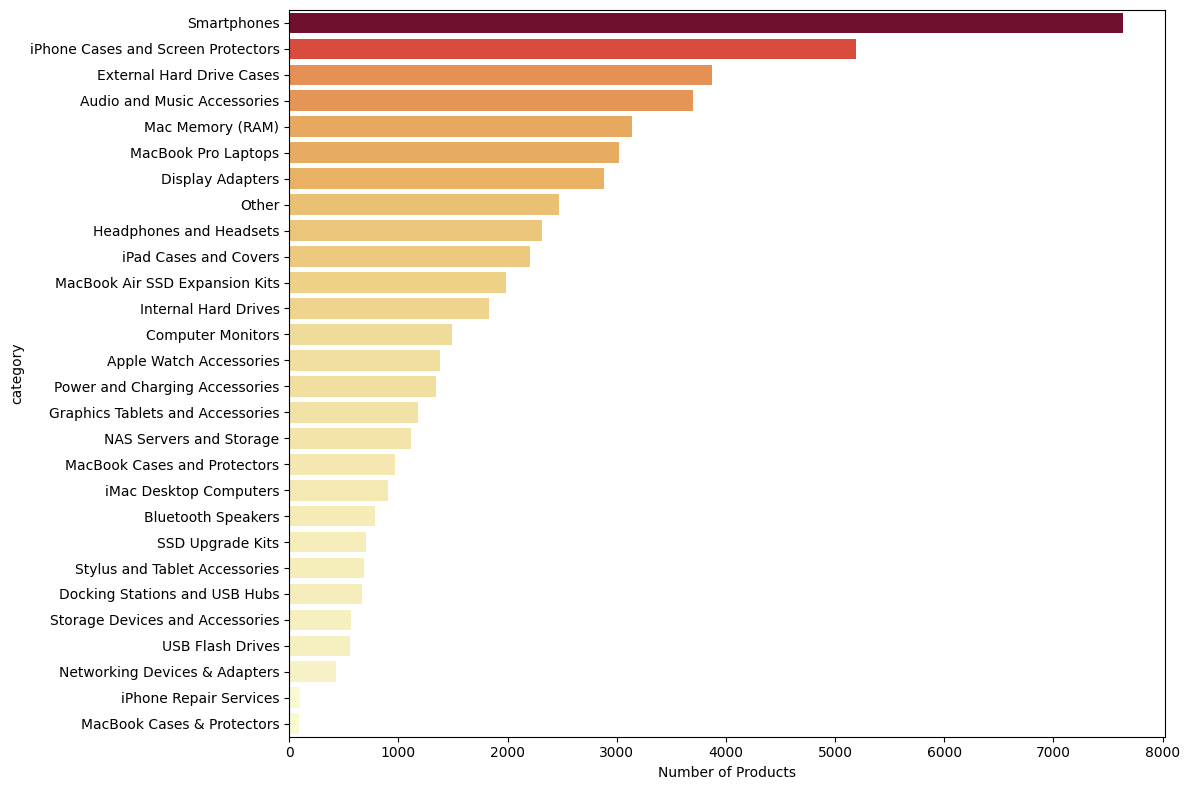

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get counts per category in descending order
counts = category_type_orderlines['category'].value_counts()
categories = counts.index
values = counts.values

# Normalize counts for colormap
norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.YlOrRd(norm(values))  # Use a heatmap colormap

plt.figure(figsize=(12, 8))
sns.barplot(
    y=categories,
    x=values,
    palette=colors
)
plt.xlabel('Number of Products')
plt.tight_layout()
plt.show()

In [ ]:
num_categories = category_type_orderlines['category'].nunique()
print(f"Number of product categories: {num_categories}")

Number of product categories: 28


## What categories are the most expensive ones

In [ ]:
# Calculate mean price per category
mean_price_by_category = category_type_df.groupby('category')['price'].mean().sort_values(ascending=False)
print(mean_price_by_category)

category
iMac Desktop Computers                3975.400252
MacBook Pro Laptops                   2014.693888
NAS Servers and Storage               1187.778515
External Hard Drive Cases              751.521797
Other                                  697.424550
Graphics Tablets and Accessories       661.610533
Computer Monitors                      512.678556
MacBook Air SSD Expansion Kits         404.087471
SSD Upgrade Kits                       367.130994
Smartphones                            341.654488
Docking Stations and USB Hubs          309.746421
iPad Cases and Covers                  269.561071
Storage Devices and Accessories        236.202733
Apple Watch Accessories                221.071706
Internal Hard Drives                   193.915905
Bluetooth Speakers                     190.822327
Mac Memory (RAM)                       179.994120
Headphones and Headsets                148.676011
MacBook Cases & Protectors             121.548533
Audio and Music Accessories            12

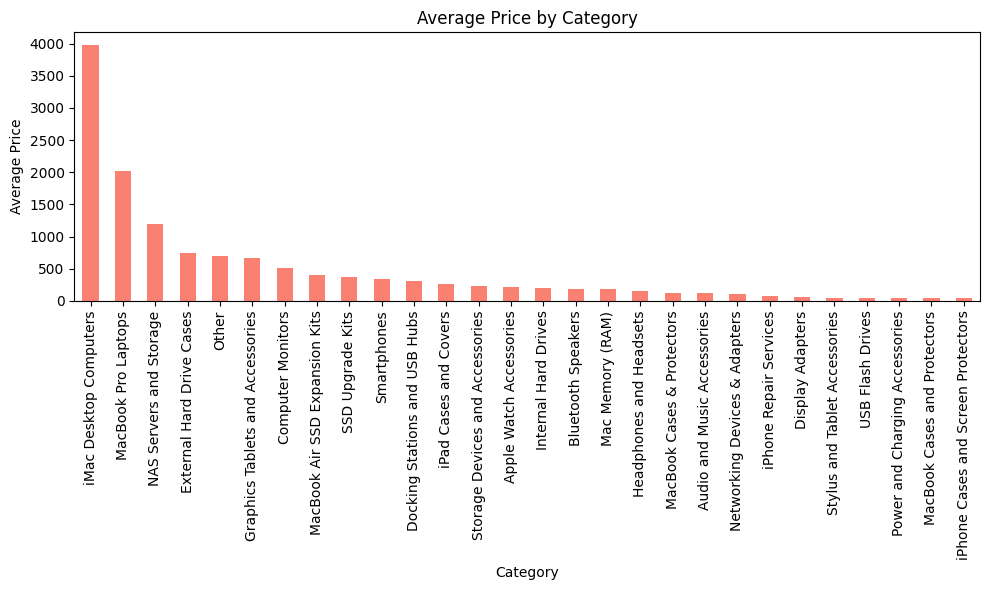

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
mean_price_by_category.plot(kind='bar', color='salmon')
plt.title('Average Price by Category')
plt.xlabel('Category')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

## Price Category with total revenue

## Creating the revenue column

In [ ]:
category_type_orderlines['revenue'] = category_type_orderlines['unit_price'] * category_type_orderlines['product_quantity']

In [ ]:
def price_category(price):
    if price < 50:
        return "Low Price"
    elif price < 200:
        return "Medium Price"
    elif price < 600:
        return "High Price"
    else:
        return "Premium"

# Adjusted for your products DataFrame
category_type_orderlines["price_category"] = category_type_orderlines["price"].apply(price_category)

/tmp/ipykernel_5374/1321677232.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


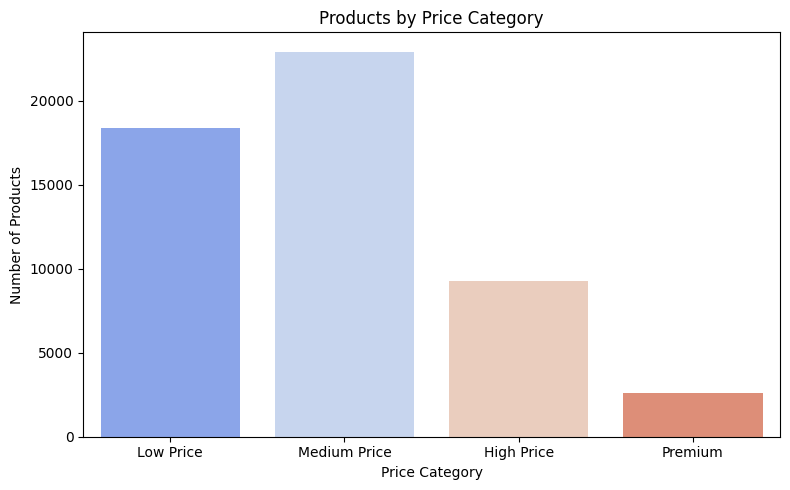

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(
    x='price_category',
    data=category_type_orderlines,
    order=['Low Price', 'Medium Price', 'High Price', 'Premium'],
    palette='coolwarm'
)
plt.title('Products by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

## Revenue by Price category

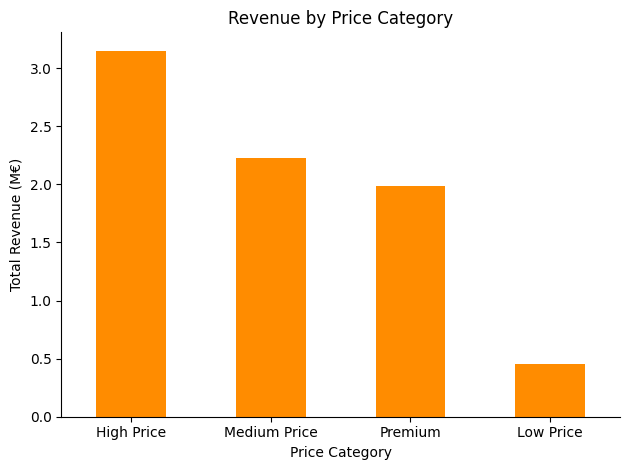

In [ ]:
import matplotlib.pyplot as plt

# Calculate total revenue per price category (in millions)
revenue_price = (
    category_type_orderlines.groupby('price_category')['revenue']
    .sum()
    .sort_values(ascending=False) / 1_000_000
)

# Plot
ax = revenue_price.plot(kind="bar", color="darkorange")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Revenue by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Total Revenue (M€)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Category of products that generate the most revenue

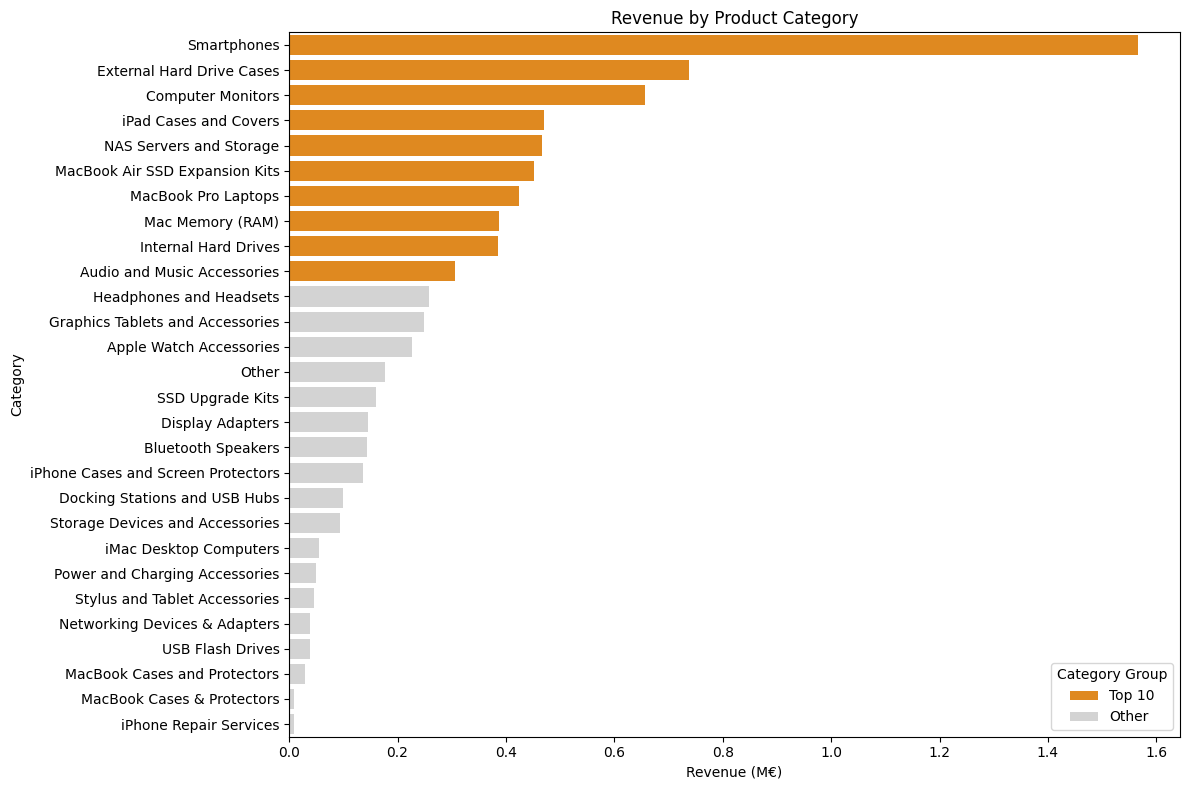

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sum revenue per category (in millions)
category_revenue = (
    category_type_orderlines.groupby('category')['revenue']
    .sum()
    .reset_index()
    .sort_values('revenue', ascending=False)
)
category_revenue['revenue_million'] = category_revenue['revenue'] / 1_000_000

# Identify top 10 categories
top10 = category_revenue.head(10)['category']

# Add a highlight column
category_revenue['highlight'] = category_revenue['category'].apply(lambda x: 'Top 10' if x in top10.values else 'Other')

# Plot with pastel palette and highlight
plt.figure(figsize=(12, 8))
sns.barplot(
    data=category_revenue,
    y='category',
    x='revenue_million',
    hue='highlight',
    palette={'Top 10': 'darkorange', 'Other': 'lightgray'},
    dodge=False
)
plt.xlabel('Revenue (M€)')
plt.ylabel('Category')
plt.title('Revenue by Product Category')
plt.legend(title='Category Group')
plt.tight_layout()
plt.show()

# Discount strategy

In [ ]:
category_type_orderlines["discount"] = category_type_orderlines["price"] - category_type_orderlines["unit_price"]

In [ ]:
category_type_orderlines["discount_pct"] = (category_type_orderlines["discount"] / category_type_orderlines["price"]) * 100
category_type_orderlines["discount_pct"] = category_type_orderlines["discount_pct"].round(2)

## How many products are being discounted overall

In [ ]:
# Count discounted products
discounted_count = category_type_orderlines[category_type_orderlines["discount"] > 0].shape[0]
print(f"Number of discounted products: {discounted_count}")

Number of discounted products: 49404


## The percentage of discounted products out of all products:

In [ ]:
total_products = category_type_orderlines.shape[0]
discounted_pct = (discounted_count / total_products) * 100
print(f"Percentage of discounted products: {discounted_pct:.2f}%")

Percentage of discounted products: 92.81%


Summary: The analysis shows that 92.81% of products are discounted, indicating the absence of a clearly defined or effectively implemented discount strategy.

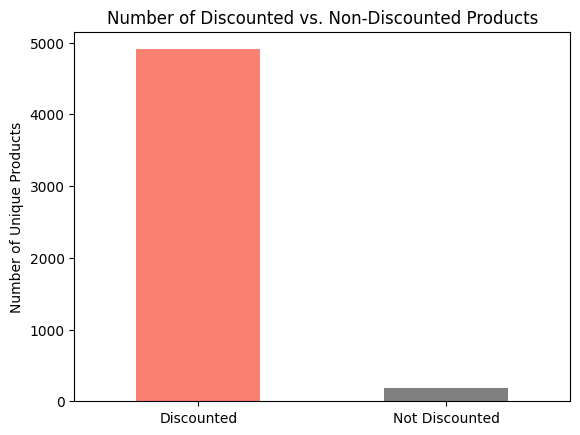

In [ ]:
import matplotlib.pyplot as plt

# Group by SKU and check if any order line for that SKU was discounted
product_discounted = category_type_orderlines.groupby('sku')['discount'].apply(lambda x: (x > 0).any())

# Count discounted and not discounted products
discount_counts = product_discounted.value_counts()

# Plot with discounted in red
colors = ['salmon' if discounted else 'gray' for discounted in discount_counts.index]

discount_counts.plot(kind='bar', color=colors)
plt.xticks([0, 1], ['Discounted', 'Not Discounted'], rotation=0)
plt.ylabel('Number of Unique Products')
plt.title('Number of Discounted vs. Non-Discounted Products')
plt.xlabel('')  # Remove x-axis label
plt.show()

## Discount categorization

In [ ]:
category_type_orderlines["discount_category"] = pd.cut(
    category_type_orderlines["discount_pct"],
    bins=[-1, 0, 10, 25, 50, 100],
    labels=["No discount", "Small (0-10%)", "Medium (10-25%)", "High (25-50%)", "Very high"]
)

## What category is being the most discounted?

In [ ]:
# Calculate average discount percentage per category
avg_discount_by_category = (
    category_type_orderlines.groupby('category')['discount_pct']
    .mean()
    .reset_index()
    .sort_values('discount_pct', ascending=False)
    .head(10)
)

print(avg_discount_by_category)

                              category  discount_pct
21     Storage Devices and Accessories     33.577958
18      Power and Charging Accessories     33.303620
13        MacBook Cases and Protectors     31.102461
26  iPhone Cases and Screen Protectors     30.184915
8              Headphones and Headsets     28.815783
25               iPad Cases and Covers     27.902591
24              iMac Desktop Computers     24.261874
5        Docking Stations and USB Hubs     23.331627
14                 MacBook Pro Laptops     22.171448
16       Networking Devices & Adapters     21.774126


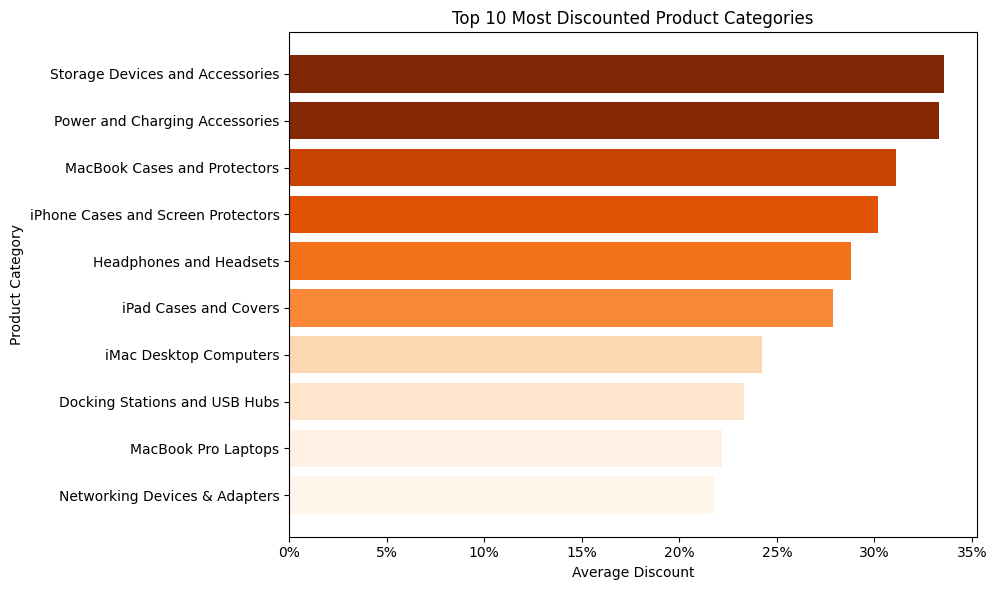

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate average discount percentage per category and get top 10
avg_discount_by_category = (
    category_type_orderlines.groupby('category')['discount_pct']
    .mean()
    .reset_index()
    .sort_values('discount_pct', ascending=False)
    .head(10)
)

# Normalize values for colormap
norm = plt.Normalize(avg_discount_by_category['discount_pct'].min(), avg_discount_by_category['discount_pct'].max())
colors = plt.cm.Oranges(norm(avg_discount_by_category['discount_pct']))

plt.figure(figsize=(10, 6))
bars = plt.barh(
    avg_discount_by_category['category'],
    avg_discount_by_category['discount_pct'],
    color=colors
)
plt.xlabel('Average Discount')
plt.ylabel('Product Category')
plt.title('Top 10 Most Discounted Product Categories')
plt.tight_layout()
plt.gca().invert_yaxis()  # Highest at the top

# Format x-axis ticks as percentages
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.show()

## Demand based on discounts

/tmp/ipykernel_5374/2705334063.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


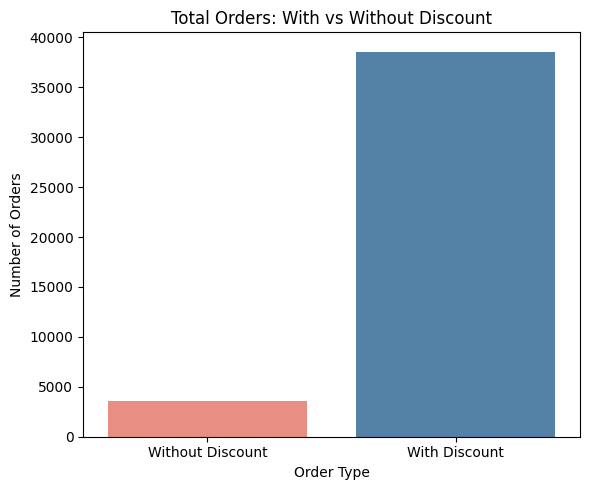

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a column to indicate if there was a discount
category_type_orderlines['has_discount'] = category_type_orderlines['discount_pct'] > 0

# Count unique orders for each group
orders_discount = (
    category_type_orderlines.groupby('has_discount')['id_order']
    .nunique()
    .reset_index()
)

orders_discount['discount_label'] = orders_discount['has_discount'].map({True: 'With Discount', False: 'Without Discount'})

plt.figure(figsize=(6, 5))
sns.barplot(
    data=orders_discount,
    x='discount_label',
    y='id_order',
    palette=['salmon', 'steelblue']
)
plt.xlabel('Order Type')
plt.ylabel('Number of Orders')
plt.title('Total Orders: With vs Without Discount')
plt.tight_layout()
plt.show()

## Discount impact on revenue

## Seasonality perspective on the discount and its impact on the revenue

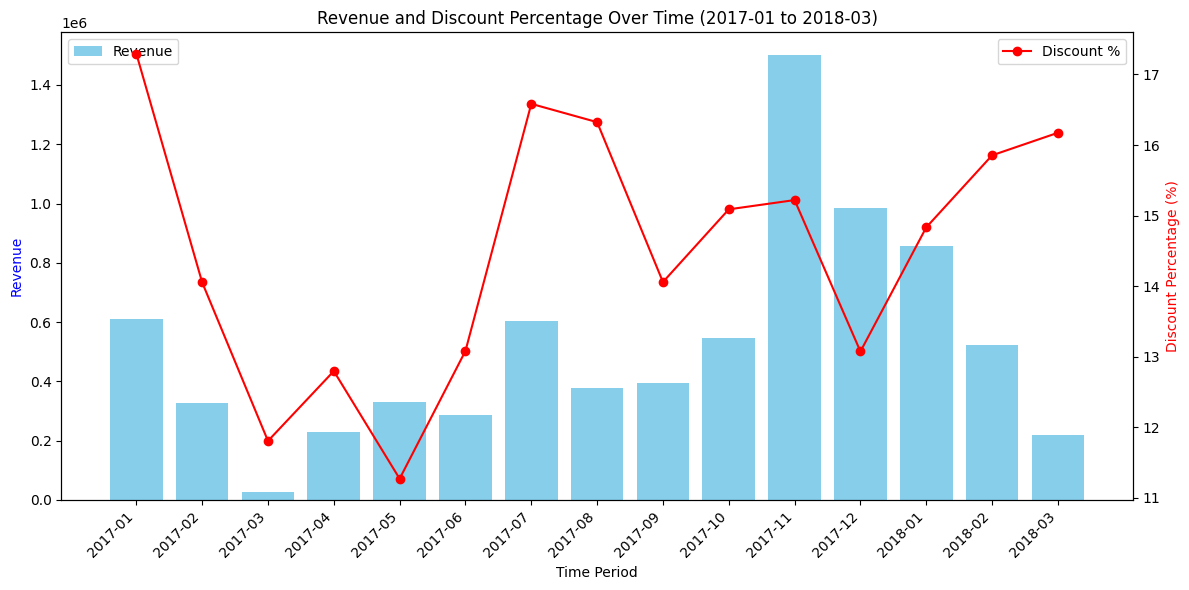

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ... (previous data preparation code)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for revenue
ax1.bar(revenue_by_period['period'].astype(str), revenue_by_period['revenue'], color='skyblue', label='Revenue')
ax1.set_xlabel('Time Period')
ax1.set_ylabel('Revenue', color='blue')

# Right y-axis for discount percentage (red line)
ax2 = ax1.twinx()
ax2.plot(revenue_by_period['period'].astype(str), revenue_by_period['discount_pct'], color='red', marker='o', label='Discount %')
ax2.set_ylabel('Discount Percentage (%)', color='red')

# Rotate x-axis labels for readability
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Revenue and Discount Percentage Over Time (2017-01 to 2018-03)')
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure you have a discount category column, e.g.:
# category_type_orderlines['discount_category'] = pd.cut(
#     category_type_orderlines['discount_pct'],
#     bins=[-1, 0, 10, 25, 50, 100],
#     labels=["No discount", "Small (0-10%)", "Medium (10-25%)", "High (25-50%)", "Very high"]
# )

# Sum revenue per discount category
revenue_by_discount = (
    category_type_orderlines.groupby('discount_category')['revenue']
    .sum()
    .reset_index()
    .sort_values('revenue', ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=revenue_by_discount,
    x='discount_category',
    y='revenue',
    palette='crest'
)
plt.xlabel('Discount Category')
plt.ylabel('Total Revenue (€)')
plt.title('Revenue by Discount Category')
plt.ticklabel_format(style='plain', axis='y')  # Remove scientific notation
plt.tight_layout()
plt.show()

## Categories of products in relation with discount and revenue

### Smartphones

/tmp/ipykernel_9670/4289640431.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


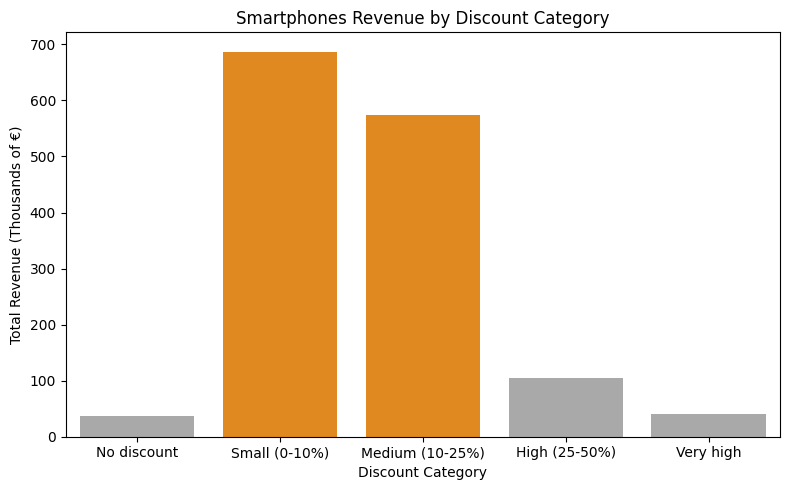

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Divide revenue by 1,000 for thousands of euros
revenue_by_discount['revenue_thousands'] = revenue_by_discount['revenue'] / 1000

# Define custom palette
custom_palette = {
    "No discount": "darkgray",
    "Small (0-10%)": "darkorange",
    "Medium (10-25%)": "darkorange",
    "High (25-50%)": "darkgray",
    "Very high": "darkgray"
}

plt.figure(figsize=(8, 5))
sns.barplot(
    data=revenue_by_discount,
    x='discount_bin',
    y='revenue_thousands',
    palette=custom_palette
)
plt.xlabel('Discount Category')
plt.ylabel('Total Revenue (Thousands of €)')
plt.title('Smartphones Revenue by Discount Category')
plt.tight_layout()
plt.show()

Interpretation:

The plot shows how revenue from the Smartphones category is distributed across different discount levels.
Most revenue comes from orders with small (0–10%) and medium (10–25%) discounts, highlighted in orange.
Orders with no discount, high (25–50%), or very high discounts contribute much less to total revenue.
This suggests that moderate discounts are most effective for driving revenue in the Smartphones category, while deep discounts or no discounts are less impactful.
Key Takeaway:
Applying small to medium discounts on smartphones maximizes revenue. Extreme discounts or no discounts do not generate as much revenue.



### Iphone Cases and Screen Protectors

/tmp/ipykernel_9670/2254122590.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iphone_cases_df['discount_bin'] = pd.cut(
/tmp/ipykernel_9670/2254122590.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iphone_cases_df.groupby('discount_bin')['revenue']
/tmp/ipykernel_9670/2254122590.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


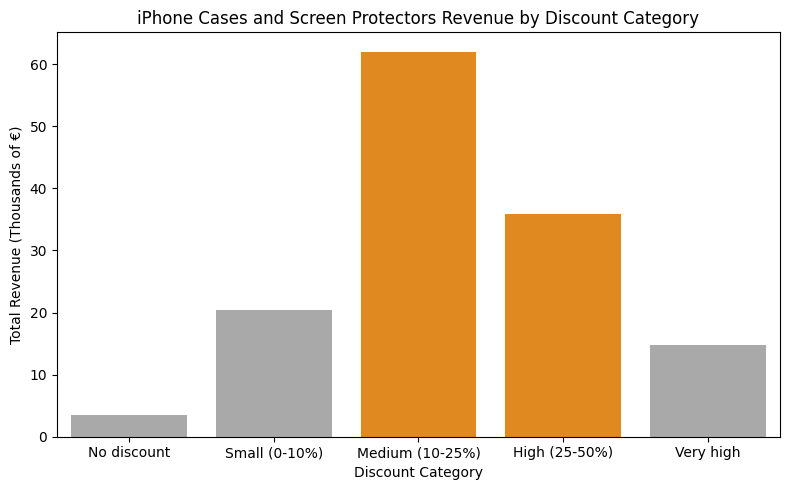

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for iPhone Cases and Screen Protectors category
iphone_cases_df = category_type_orderlines[category_type_orderlines['category'] == "iPhone Cases and Screen Protectors"]

# Create discount bins
iphone_cases_df['discount_bin'] = pd.cut(
    iphone_cases_df['discount_pct'],
    bins=[-1, 0, 10, 25, 50, 100],
    labels=["No discount", "Small (0-10%)", "Medium (10-25%)", "High (25-50%)", "Very high"]
)

# Calculate revenue per discount bin (in thousands of euros)
revenue_by_discount_iphone = (
    iphone_cases_df.groupby('discount_bin')['revenue']
    .sum()
    .reset_index()
)
revenue_by_discount_iphone['revenue_thousands'] = revenue_by_discount_iphone['revenue'] / 1000

# Define custom palette
custom_palette = {
    "No discount": "darkgray",
    "Small (0-10%)": "darkgray",
    "Medium (10-25%)": "darkorange",
    "High (25-50%)": "darkorange",
    "Very high": "darkgray"
}

plt.figure(figsize=(8, 5))
sns.barplot(
    data=revenue_by_discount_iphone,
    x='discount_bin',
    y='revenue_thousands',
    palette=custom_palette
)
plt.xlabel('Discount Category')
plt.ylabel('Total Revenue (Thousands of €)')
plt.title('iPhone Cases and Screen Protectors Revenue by Discount Category')
plt.tight_layout()
plt.show()

### MacBook Pro Laptops

/tmp/ipykernel_9670/1825084948.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  macbook_df['discount_bin'] = pd.cut(
/tmp/ipykernel_9670/1825084948.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  macbook_df.groupby('discount_bin')['revenue']
/tmp/ipykernel_9670/1825084948.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


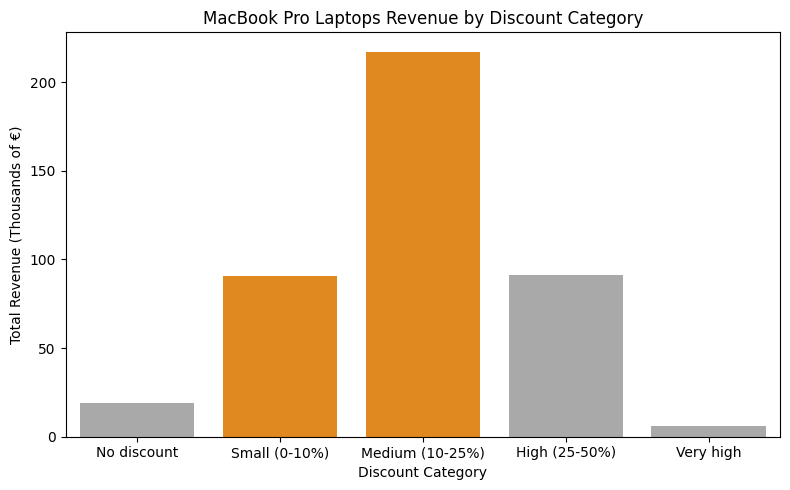

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for MacBook Pro Laptops category
macbook_df = category_type_orderlines[category_type_orderlines['category'] == "MacBook Pro Laptops"]

# Create discount bins
macbook_df['discount_bin'] = pd.cut(
    macbook_df['discount_pct'],
    bins=[-1, 0, 10, 25, 50, 100],
    labels=["No discount", "Small (0-10%)", "Medium (10-25%)", "High (25-50%)", "Very high"]
)

# Calculate revenue per discount bin (in thousands of euros)
revenue_by_discount_macbook = (
    macbook_df.groupby('discount_bin')['revenue']
    .sum()
    .reset_index()
)
revenue_by_discount_macbook['revenue_thousands'] = revenue_by_discount_macbook['revenue'] / 1000

# Define custom palette
custom_palette = {
    "No discount": "darkgray",
    "Small (0-10%)": "darkorange",
    "Medium (10-25%)": "darkorange",
    "High (25-50%)": "darkgray",
    "Very high": "darkgray"
}

plt.figure(figsize=(8, 5))
sns.barplot(
    data=revenue_by_discount_macbook,
    x='discount_bin',
    y='revenue_thousands',
    palette=custom_palette
)
plt.xlabel('Discount Category')
plt.ylabel('Total Revenue (Thousands of €)')
plt.title('MacBook Pro Laptops Revenue by Discount Category')
plt.tight_layout()
plt.show()

### MacBook Cases and Protectors

/tmp/ipykernel_9670/989069073.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  macbook_cases_df['discount_bin'] = pd.cut(
/tmp/ipykernel_9670/989069073.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  macbook_cases_df.groupby('discount_bin')['revenue']
/tmp/ipykernel_9670/989069073.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


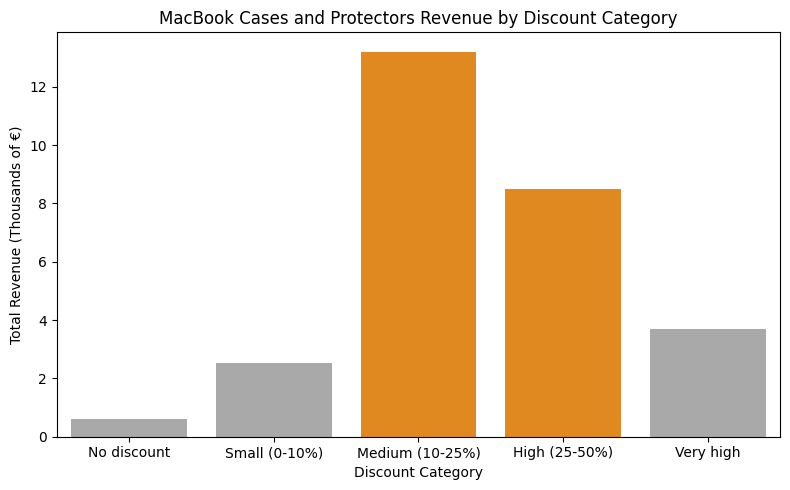

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for MacBook Cases and Protectors category
macbook_cases_df = category_type_orderlines[category_type_orderlines['category'] == "MacBook Cases and Protectors"]

# Create discount bins
macbook_cases_df['discount_bin'] = pd.cut(
    macbook_cases_df['discount_pct'],
    bins=[-1, 0, 10, 25, 50, 100],
    labels=["No discount", "Small (0-10%)", "Medium (10-25%)", "High (25-50%)", "Very high"]
)

# Calculate revenue per discount bin (in thousands of euros)
revenue_by_discount_cases = (
    macbook_cases_df.groupby('discount_bin')['revenue']
    .sum()
    .reset_index()
)
revenue_by_discount_cases['revenue_thousands'] = revenue_by_discount_cases['revenue'] / 1000

# Define custom palette
custom_palette = {
    "No discount": "darkgray",
    "Small (0-10%)": "darkgray",
    "Medium (10-25%)": "darkorange",
    "High (25-50%)": "darkorange",
    "Very high": "darkgray"
}

plt.figure(figsize=(8, 5))
sns.barplot(
    data=revenue_by_discount_cases,
    x='discount_bin',
    y='revenue_thousands',
    palette=custom_palette
)
plt.xlabel('Discount Category')
plt.ylabel('Total Revenue (Thousands of €)')
plt.title('MacBook Cases and Protectors Revenue by Discount Category')
plt.tight_layout()
plt.show()